## Results of Host Prediction
### Dataset: EMBL mapping, Vertebrates, Non-IDV

**Models**: FNN, CNN, RNN, LSTM, TF

**Positional Embedding**: Sin-Cos

**Maximum Sequence Length**: 1036

**Classification**: Multi-class

**\# classes**: 5

**\# train samples** = 

**\# validation samples** = 

**\# test samples** = 

In [1]:
import seaborn

In [2]:
seaborn.__version__

'0.13.2'

In [3]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path

['/home/blessyantony/miniconda3/envs/haven/lib/python311.zip',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/lib-dynload',
 '',
 '/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../..',
 '/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../..']

In [4]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import mannwhitneyu, wilcoxon, ranksums, iqr

from src.utils import utils, evaluation_utils, visualization_utils

In [5]:
def classwise_auprc_analysis(output_filepaths, figure_output_filepath=None):
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    auprc_results = []
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        df.fillna(0, inplace=True)
        print(f"Read output {model} = {df.shape}")
        
        cols = df.columns
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class":metadata_formatted}, inplace=True)
    sns.set_context("paper")
    sns.axes_style("whitegrid")
    
    FIGURE_CONFIG = {
        "figsize": (12, 6),
        "xtick.labelsize": 14,
        "ytick.labelsize": 14    
    }
    
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())
    
    visualization_utils.pre_plot_config(FIGURE_CONFIG)
    ax = sns.boxplot(data=auprc_results_df, x="class", y="auprc", hue="model", 
                     order=metadata_sorted, linewidth=1.5, fliersize=5, linecolor="black",
                     palette=color_palette)
    
    bg_colors = [ "gray", "white",]
    
    plt.draw()
    
    ax.set_ylim(0, 1)
    ax.set_ylabel("AUPRC", size=14)
    ax.set_xlabel("", size=0, labelpad=0)
    sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, 1), ncol=5, title=None, frameon=False)
    plt.setp(ax.get_legend().get_texts(), fontsize=14)
    visualization_utils.wrap_ticklabels(ax, axis="x")
    
    n_classes = auprc_results_df["class"].nunique()
    for i in range(n_classes):
        ax.axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    if figure_output_filepath:
        visualization_utils.view(figure_output_filepath)
    plt.show()

In [59]:
def macro_and_classwise_auprc_analysis(output_filepaths, classes, figure_output_filepath=None):
    auprc_results = []
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    print(classes)
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {df.shape}")
        df.fillna(0, inplace=True)
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df = pd.concat([auprcs_df, 
                                   pd.DataFrame({"class": ["Macro-AUPRC"], "auprc": [auprcs_df["auprc"].mean()]})
                                  ], ignore_index=True)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    #metadata_sorted["Macro-AUPRC"] = 0
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class": metadata_formatted}, inplace=True)
    models = list(auprc_results_df["model"].unique())
    plt.rcParams['xtick.labelsize'] = 16
    plt.rcParams['ytick.labelsize'] = 16
    plt.rcParams.update({'font.size': 16})
    fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=True, gridspec_kw={"width_ratios": [1, 6]})
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    # sns.boxplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
    #             palette=color_palette, ax=axs[0],
    #             linewidth=1.5, fliersize=5, linecolor="black", legend=False)

    sns.barplot(data=auprc_results_df[auprc_results_df["class"] == "Macro-AUPRC"], x="class", y="auprc", hue="model", fill=True,
                palette=color_palette, ax=axs[0],
                linewidth=1.5, legend=False)
    
    #sns.boxplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, fliersize=5, linecolor="black", order=metadata_sorted, palette=color_palette, ax=axs[1])
    sns.barplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", linewidth=1.5, order=metadata_sorted, palette=color_palette, ax=axs[1])
    #sns.violinplot(data=auprc_results_df[auprc_results_df["class"].isin(metadata_formatted.values())], x="class", y="auprc", hue="model", orient="v", order=metadata_sorted, palette=color_palette, ax=axs[1], legend="auto")
    # plt.draw()
    axs[0].set_ylim(0.0, 1)
    axs[1].set_ylim(0.0, 1)
    axs[0].set_ylabel("AUPRC", size=18)
    axs[0].set_xlabel("", size=0, labelpad=0)
    axs[1].set_xlabel("", size=0, labelpad=0)
    axs[1].set_title("UniRef90 Proteins | Virus Genus Split | Host Species", size=16)
    #sns.move_legend(axs[1], "lower center", bbox_to_anchor=(.5, 1), ncol=1, title=None, frameon=False)
    sns.move_legend(axs[1], "upper left", title=None, bbox_to_anchor=(1, 1))
    plt.setp(axs[1].get_legend().get_texts(), fontsize=16)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(axs[1], axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)-1):
        axs[1].axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    plt.subplots_adjust(wspace=0.01)
    plt.tight_layout()
    plt.savefig(figure_output_filepath, dpi=1024)
    plt.subplots_adjust(wspace=-.001)
    plt.show()
    return auprc_results_df

['Human', 'Pig', 'Domestic cattle', 'Red junglefowl']
Read output BLAST = (44793, 10)
Read output ProtT5 = (20207, 7)
Read output HAVEN = (18473, 7)


/home/blessyantony/miniconda3/envs/haven/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:980: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


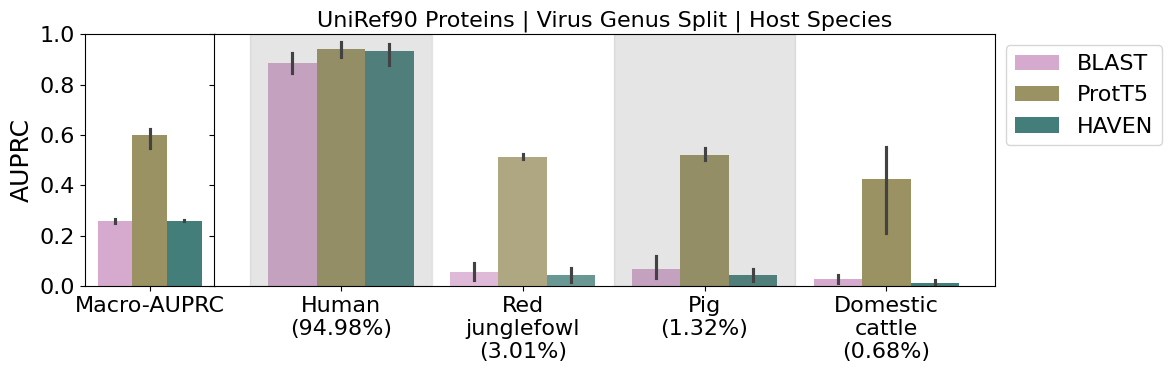

In [138]:
output_filepaths = {
    "BLAST": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_virus_genus_host_species_vertebrates_non_idv_t0.01_c4_seq_len_in_99percentile/20260326/host_multi/virus_genus_split/homology/virus_host_tax_id_multi_blast_blast_output.csv"),
    "ProtT5": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20260611/host_multi/virus_genus_split/external/uniref90_prott5_prot_t5_base_mt_uniref50_msl2048_fnn_2l_d768_lr3e-4_output.csv"),
    "HAVEN": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20260526a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-4_output.csv"),
    
}

classes = ["Human", "Pig", "Domestic cattle", "Red junglefowl"]
auprc_results_df = macro_and_classwise_auprc_analysis(output_filepaths, classes, figure_output_filepath=os.path.join(os.getcwd(), "..","..", "..", "..", "output/visualization/20260901/host_multi_all_models_uniref90_genus_protein_auprc.pdf"))

In [156]:
def classwise_probability_analysis(output_filepaths, classes, figure_output_filepath=None):
    auprc_results = []
    id_col="uniref90_id"
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    print(classes)
    dfs = []
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {df.shape}")
        df.fillna(0, inplace=True)
        df["model"] = model
        itrs = df[itr_col].unique()
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            df_itr["model"] = model
            df_itr[itr_col] = itr
            melted_df = df_itr[classes + [id_col, y_true_col, itr_col, "model"]].melt(id_vars=[id_col, y_true_col, itr_col, "model"], var_name="class", value_name="probability")
            melted_df["true_class_probability"] = melted_df.apply(lambda x: x["class"] == x[y_true_col], axis=1)
            dfs.append(melted_df)
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    #metadata_sorted["Macro-AUPRC"] = 0
    df = pd.concat(dfs, ignore_index=True)
    df.replace({"class": metadata_formatted}, inplace=True)
    models = list(df["model"].unique())
    plt.rcParams['xtick.labelsize'] = 16
    plt.rcParams['ytick.labelsize'] = 16
    plt.rcParams.update({'font.size': 16})
    fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=False, sharey=False)
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())

    ax = axs[0]
    sns.boxplot(data=df, x="class", y="probability", hue="model", #style="true_class_probability",
                palette=color_palette, ax=ax)
    ax.axhline((1/len(classes)), ls="--")
    ax.set_ylim(0.0, 1)
    ax.set_ylabel("Predicted Probability", size=18)
    ax.set_xlabel("", size=0, labelpad=0)
    ax.set_title("UniRef90 Proteins | Virus Genus Split | Host Species", size=16)
    sns.move_legend(ax, "upper left", title=None, bbox_to_anchor=(1, 1))
    plt.setp(ax.get_legend().get_texts(), fontsize=16)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(ax, axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)):
        ax.axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)


    ax = axs[1]
    sns.boxplot(data=df[df["true_class_probability"] == True], x="class", y="probability", hue="model", #style="true_class_probability",
                palette=color_palette, ax=ax)
    ax.axhline((1/len(classes)), ls="--")
    ax.set_ylim(0.0, 1)
    ax.set_ylabel("Predicted Probability\nfor Ground-truth labels", size=18)
    ax.set_xlabel("", size=0, labelpad=0)
    #ax.set_title("UniRef90 Proteins | Virus Genus Split | Host Species", size=16)
    sns.move_legend(ax, "upper left", title=None, bbox_to_anchor=(1, 1))
    plt.setp(ax.get_legend().get_texts(), fontsize=16)
    #visualization_utils.wrap_ticklabels(axs[0], axis="x")
    visualization_utils.wrap_ticklabels(ax, axis="x")

    bg_colors = [ "gray", "white",]
    
    for i in range(len(classes)):
        ax.axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    plt.tight_layout()
    plt.savefig(figure_output_filepath, dpi=1024)
    plt.show()
    return df

['Human', 'Pig', 'Domestic cattle', 'Red junglefowl']
Read output BLAST = (44793, 10)


/tmp/ipykernel_1073481/318538029.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_itr["model"] = model
/tmp/ipykernel_1073481/318538029.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_itr[itr_col] = itr
/tmp/ipykernel_1073481/318538029.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

Read output ProtT5 = (20207, 7)


/tmp/ipykernel_1073481/318538029.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_itr["model"] = model
/tmp/ipykernel_1073481/318538029.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_itr[itr_col] = itr
/tmp/ipykernel_1073481/318538029.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.ht

Read output HAVEN = (18473, 7)


/tmp/ipykernel_1073481/318538029.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_itr["model"] = model
/tmp/ipykernel_1073481/318538029.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_itr[itr_col] = itr
/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/results-analysis/uniref90/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels

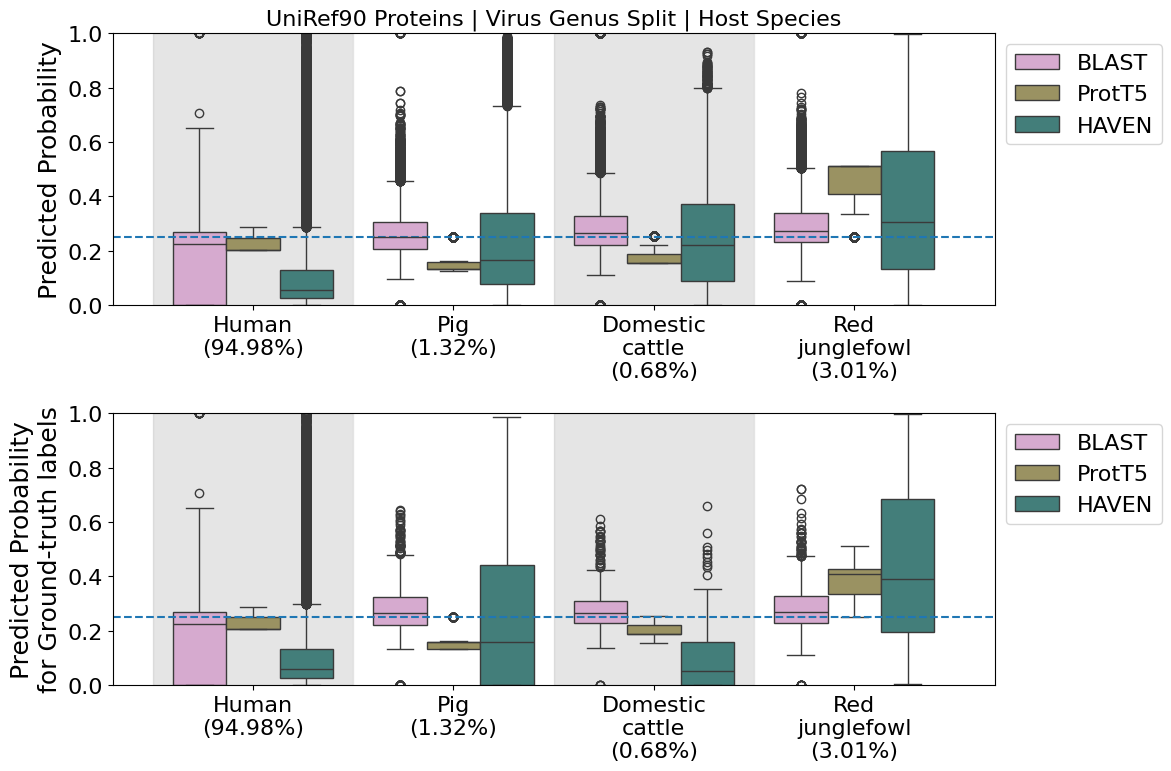

In [157]:
y = classwise_probability_analysis(output_filepaths, classes, figure_output_filepath=os.path.join(os.getcwd(), "..","..", "..", "..", "output/visualization/20260901/host_multi_all_models_uniref90_genus_protein_class_probabilities.pdf"))

In [153]:
y

,uniref90_id,y_true,itr,model,class,probability,true_class_probability
0,UniRef90_A0A7M1VCS1,Red junglefowl,0,BLAST,Human (94.98%),0.266941,False
1,UniRef90_A0A7M1VFJ3,Red junglefowl,0,BLAST,Human (94.98%),0.337539,False
2,UniRef90_A0A386BX41,Red junglefowl,0,BLAST,Human (94.98%),0.199167,False
3,UniRef90_A0A386BXA1,Human,0,BLAST,Human (94.98%),0.000000,True
4,UniRef90_A0A386BXY6,Red junglefowl,0,BLAST,Human (94.98%),0.212947,False
...,...,...,...,...,...,...,...
333887,UniRef90_A0A0S1RZ22,Human,3,HAVEN,Red junglefowl (3.01%),0.135259,False
333888,UniRef90_A0A1S6KI22,Human,3,HAVEN,Red junglefowl (3.01%),0.261448,False
333889,UniRef90_H9XQS7,Human,3,HAVEN,Red junglefowl (3.01%),0.206605,False
333890,UniRef90_V5JYL2,Human,3,HAVEN,Red junglefowl (3.01%),0.141118,False


In [46]:
def combine_output_files(output_filepath_template, itrs, output_filename):
    dfs = []
    for itr in itrs:
        df = pd.read_csv(os.path.join(os.getcwd(), "..","..", "..", "..", output_filepath_template.format(itr=itr)), index_col=0)
        df["itr"] = int(itr)
        dfs.append(df)
    pd.concat(dfs).to_csv(output_filename)

In [9]:
combine_output_files(os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20260526a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_itr{itr}_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-4_output_itr0.csv"),
                     [1, 2, 3],
                    os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/uniref90_embl_vertebrates_non_idv_t0.01_c5_seq_len_in_99.9percentile/20260526a/host_multi/virus_genus_split/haven/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_vs30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr1e-4wd1e-4_output.csv"))